In [ ]:
import pandas as pd
import random
import numpy as np
np.random.seed(1234)
random.seed(1234)
df = pd.read_csv("../data/train.csv")


In [3]:
df.Name.str.split("[,.]", expand=True)

,0,1,2,3
0,Braund,Mr,Owen Harris,NaN
1,Cumings,Mrs,John Bradley (Florence Briggs Thayer),NaN
2,Heikkinen,Miss,Laina,NaN
3,Futrelle,Mrs,Jacques Heath (Lily May Peel),NaN
4,Allen,Mr,William Henry,NaN
...,...,...,...,...
886,Montvila,Rev,Juozas,NaN
887,Graham,Miss,Margaret Edith,NaN
888,Johnston,Miss,"Catherine Helen ""Carrie""",NaN
889,Behr,Mr,Karl Howell,NaN


In [5]:
name_df = df.Name.str.split("[,.]", expand=True).iloc[:, :3]

name_df.columns = ['first_name', 'honorific', 'last_name']

name_df.first_name = name_df.first_name.str.strip()
name_df.honorific = name_df.honorific.str.strip()
name_df.last_name = name_df.last_name.str.strip()


In [6]:
df2 = pd.concat([df, name_df['honorific']], axis=1)

In [7]:
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.style.use('ggplot')


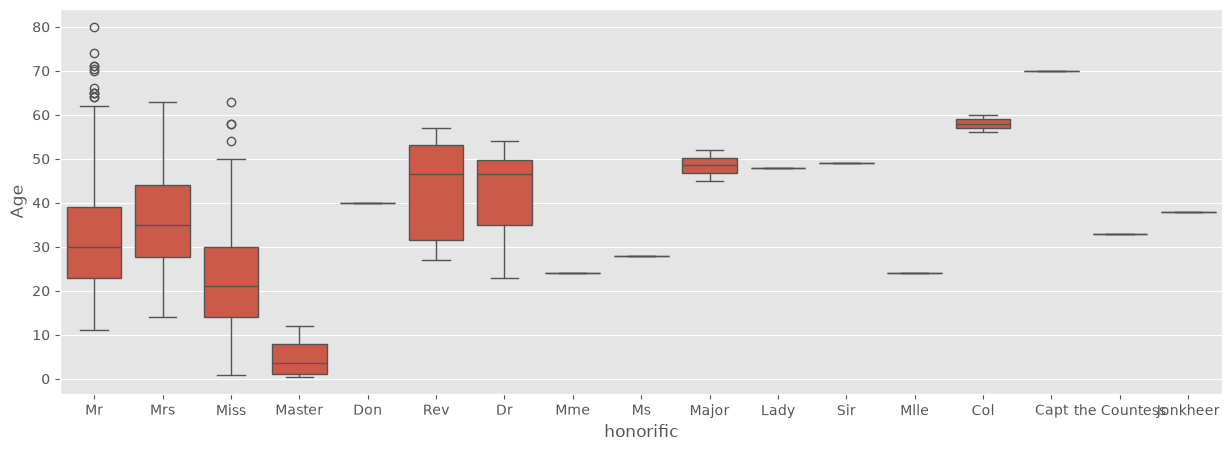

In [8]:
plt.figure(figsize=(15,5))
sns.boxplot(
    data = df2,
    x = 'honorific', y='Age'
)
plt.show()


In [9]:
hono_mean_age = df2.groupby(['honorific'], as_index=False)[['Age']].mean()

In [10]:
all_df = pd.merge(df2, hono_mean_age, on='honorific', how='left')

In [12]:
all_df.loc[all_df.Age_x.isnull(), 'Age_x'] = all_df['Age_y']

In [14]:
all_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age_x            0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
honorific        0
Age_y            0
dtype: int64

In [16]:
all_df.Age_x = all_df.Age_x.astype(int)

In [17]:
all_df

,PassengerId,Survived,Pclass,Name,Sex,Age_x,SibSp,Parch,Ticket,Fare,Cabin,Embarked,honorific,Age_y
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S,Mr,32.368090
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C,Mrs,35.898148
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,21.773973
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S,Mrs,35.898148
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S,Mr,32.368090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13.0000,NaN,S,Rev,43.166667
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30.0000,B42,S,Miss,21.773973
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21,1,2,W./C. 6607,23.4500,NaN,S,Miss,21.773973
889,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30.0000,C148,C,Mr,32.368090


In [20]:
all_df.drop(['Name', 'Ticket', 'Cabin', 'Age_y', 'PassengerId'], axis=1, inplace=True)

KeyError: "['Name', 'Ticket', 'Cabin', 'Age_y', 'PassengerId'] not found in axis"

In [22]:
all_df.honorific.value_counts()

honorific
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [23]:
all_df.loc[~all_df.honorific.isin(['Mr', 'Miss', 'Mrs']), 'honorific'] = 'Others'

In [24]:
all_df.honorific.value_counts()

honorific
Mr        517
Miss      182
Mrs       125
Others     67
Name: count, dtype: int64

In [25]:
import pickle

with open('../data/titanic.pkl', 'wb') as f:
    pickle.dump(all_df, f)

In [33]:
import requests
from bs4 import BeautifulSoup, SoupStrainer
from langchain_community.document_loaders import WebBaseLoader

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [27]:
url = "https://www.medicaltimes.com/Main/"

In [ ]:
# div, class -> view_cont ck-content clearfix
# Load = WebBaseLoader(total, bs_kwargs={'parse_only': SoupStrainer('article', id='dic_area')})

In [34]:
data = WebBaseLoader([ url + x.find('a')['href'][2:] \
for x in BeautifulSoup(requests.get(url).text).find("div", class_="midNews_main").find_all("span", class_="head")][:5],
             bs_kwargs={'parse_only' : SoupStrainer("div", class_='view_cont ck-content clearfix')}).load()

In [35]:
data

[Document(metadata={'source': 'https://www.medicaltimes.com/Main/News/NewsView.html?ID=1168528'}, page_content='\n[메디칼타임즈=이인복 기자]경피적 시술이 급속도로 확산되고 있는 판막 치료 시장에 메드트로닉이 새로운 수술용 판막을 내놓으면서 배경에 관심이 모아지고 있다.이미 경피적 승모판막 치환술(TMVR) 기기를 가지고 있는 가운데 점유율이 점점 줄어들고 있는 사업을 다시 건드렸다는 점에서 이목이 쏠리고 있는 것. 포트폴리오를 넓혀 전략을 다변화하기 위한 시도로 풀이된다.경피적 시술이 대세로 굳어지고 있는 판막 시장에 메드트로닉이 새로운 수술용 판막을 내놔 이목을  끌고 있다(사진=AI 생성)30일 의료산업계에 따르면 메드트로닉이 차세대 승모판 생체 조직 판막 \'모자이크 네오(Mosaic Neo)\'에 대해 미국 식품의약국(FDA) 승인을 획득한 것으로 파악됐다.모자이크 네오는 전통적인 외과적 승모판 치환술에 사용되는 생체조직 판막으로 개흉 수술뿐 아니라 최소침습 수술과 로봇 수술 환경에서도 사용할 수 있도록 설계된 기기다.저프로파일 구조와 새로운 밸브 홀더, 직관적인 사이징 시스템, 향상된 형광투시 가시성 등을 적용해 다양한 수술 접근법에서 활용성을 높인 것이 특징.이번 제품에서 나타난 변화는 단순한 기능 개선을 넘어선다. 기존 판막이 수술 방식에 맞춰 사용되는 구조였다면 모자이크 네오는 다양한 수술 환경에 맞춰 유연하게 적용되는 형태로 진화했기 때문이다.이는 경피적 시술의 확산으로 수술 환경이 점차 소형화되고 정밀화되는 흐름을 반영한 결과로 해석된다.이 같은 움직임이 중요한 이유는 판막 치료 시장의 구조적 변화와 맞닿아 있기 때문이다.현재 대동맥 판막에서는 TAVI 등 경피적 시술이 빠르게 확산되며 사실상 외과적 수술이 설 자리가 없어지고 있는 추세다.승모판막 역시 TMVR 중심으로 시장이 재편되는 과정에 있다. 심장 판막 분야에서 경피적 시술이 대세로 굳어지고 있